In [1]:
from utils import *
import pandas as pd
import glob, os

In [2]:
def safe_map(func):
    def wrapper(x):
        try:
            return func(x)
        except Exception:
            return None

    return wrapper

In [3]:
dfs = []
for file in glob.glob(f"../results/experiment*scaling*.csv"):
    dfs.append(pd.read_csv(file))
df = pd.concat(dfs, ignore_index=True)
for col in df.columns:
    if col.endswith("times"):
        df[col] = df[col].apply(safe_map(ast.literal_eval))
df["metadata"] = df["metadata"].apply(safe_map(ast.literal_eval))
df["solvers m"] = df["solvers m"].apply(lambda m: "-" if pd.isna(m) else m)
df["coarse m"] = df["coarse m"].apply(lambda m: "-" if pd.isna(m) else m)
df["p"] = df["p"].apply(int)

ValueError: No objects to concatenate

In [ ]:
def nice_solver_name(name):
    if "AMGX" in name:
        return "AmgX"
    if "Hybrid" in name:
        return "Hybrid Schwarz"
    if "Additive" in name:
        return "Additive Schwarz"
    return None

In [ ]:
df["best solve time"] = df["solve times"].apply(lambda times: min(times) if times else None)
df["best DoFs/s"] = df.apply(
    lambda row: row["DoFs"] / row["best solve time"] * 1000,
    axis=1,
)
df["nice solver"] = df["solver"].apply(nice_solver_name)
df["fine m val"] = df["fine m"].apply(lambda m: int(m[1:]))

In [ ]:
pivot = df.pivot_table(
    values="best DoFs/s",
    index=["p", "solver"],
    columns=["fine m val"]
)
pivot

fine m val                                                       4   \
p solver                                                              
1 AMGX(CG_L1_TRUNC, None)                                       NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)                    NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)                     NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...            NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)            NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...            NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...            NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...            NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...            NaN   
3 AMGX(CG_L1_TRUNC, None)                             419145.512035   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          214731.959278   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)           123881.673001   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  222627.582386   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  126778.864051   

fine m val                                                       5   \
p solver                                                              
1 AMGX(CG_L1_TRUNC, None)                             940982.727048   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          452059.342915   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)           175987.436874   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  454903.001585   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  183059.371870   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  216802.904754   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   93343.215991   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  378997.977838   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  159869.304056   
3 AMGX(CG_L1_TRUNC, None)                             975412.003087   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          632645.463902   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)           414481.203004   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  697503.580113   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  433094.672252   

fine m val                                                      6   \
p solver                                                             
1 AMGX(CG_L1_TRUNC, None)                             2.569129e+06   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          1.388464e+06   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)           6.253506e+05   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  1.487363e+06   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  6.414368e+05   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  6.954916e+05   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  3.261681e+05   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  1.336598e+06   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  6.037048e+05   
3 AMGX(CG_L1_TRUNC, None)                             2.043165e+06   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          1.611498e+06   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)           1.162774e+06   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  1.920131e+06   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  1.338766e+06   

fine m val                                                      7   \
p solver                                                             
1 AMGX(CG_L1_TRUNC, None)                             5.768960e+06   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          3.625040e+06   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)           2.007964e+06   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  4.200233e+06   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  2.129245e+06   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  2.651236e+06   
  CG(AdditiveSchwarz(torch.float32, Inv(torch

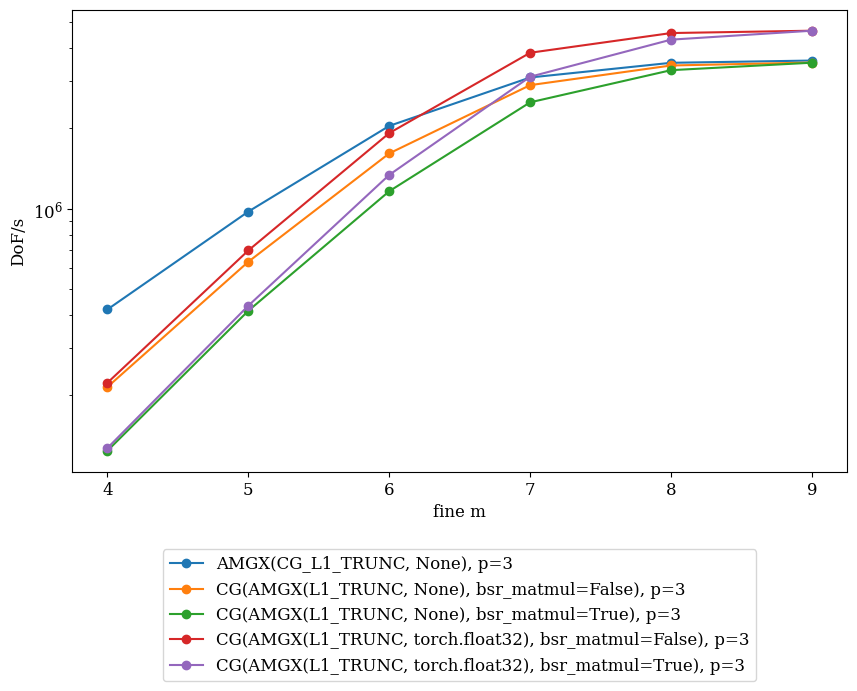

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale("log")
# ax.set_xscale("log")
for (p, solver), vals in pivot.iterrows():
    if p != 3:
        continue
    if "AMGX" not in solver:
        continue
    ax.plot(vals, label=f"{solver}, p={p}", marker='o')
ax.set_ylabel("DoF/s")
ax.set_xlabel("fine m")

#legend below the plot
ax.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=1)

fig.show()

In [ ]:
assert False

AssertionError: 

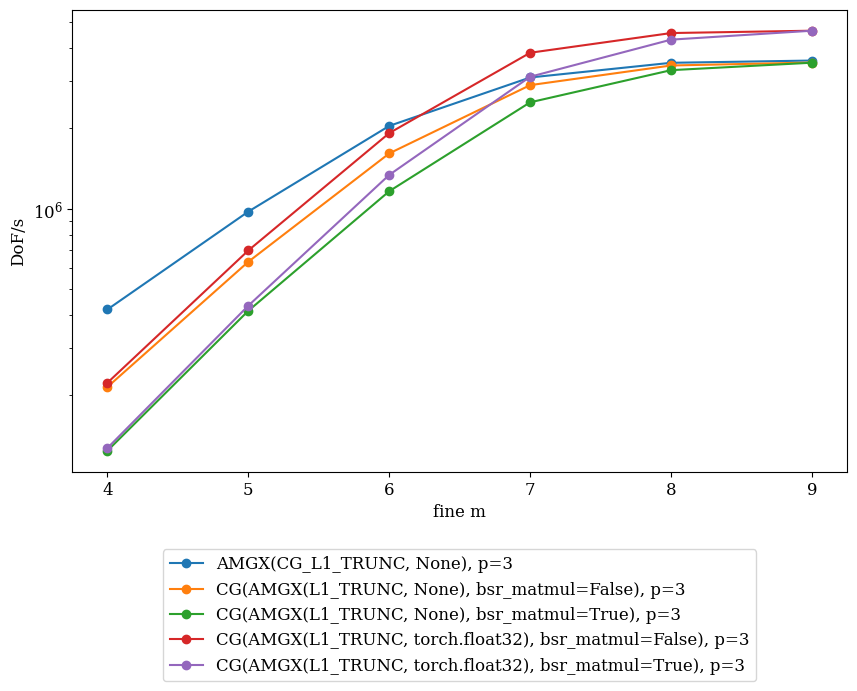

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale("log")
# ax.set_xscale("log")
for (p, solver), vals in pivot.iterrows():
    if p != 3:
        continue
    if "AMGX" not in solver:
        continue
    ax.plot(vals, label=f"{solver}, p={p}", marker='o')
ax.set_ylabel("DoF/s")
ax.set_xlabel("fine m")

#legend below the plot
ax.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=1)

fig.show()